In [6]:
import sys
import os
from pathlib import Path

import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath("../..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f"Project root: {project_root}")

from src.models import (
    gqnn,
    gqnn_shape,
    draw_circuit,
)

from src.datagen import (
    mackey_glass,
    split_and_scale_series,
    create_io_pairs,
)

Project root: /home/miron/QML/AIntern/qtsa_expressivity


In [28]:
n_qubits = 6
n_layers = 4
feature_map = "zzfm"

dev = qml.device("lightning.qubit", wires=n_qubits)

model = gqnn(
    n_layers=n_layers,
    n_qubits=n_qubits,
    dev=dev,
    fm_style=feature_map,
)

weight_shape = gqnn_shape(n_layers, n_qubits)
weights = np.random.normal(scale=0.1, size=weight_shape)

# Random input
x = np.random.rand(n_qubits)

In [29]:
from projects.expressivity_krylov.krylov.basis import get_subnetwork_unitary
from projects.expressivity_krylov.krylov.metrics import compute_krylov_expressivity
from projects.expressivity_krylov.krylov.plotting import plot_krylov_expressivity

# Setup dimensions
n_qubits = 6
n_layers = 20
feature_map = "zzfm"

weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
weights = np.random.normal(scale=0.1, size=weight_shape)
x = np.random.rand(n_qubits)

# Single qubit initial observable Z_0 in full Hilbert space
Z0 = np.kron(np.array([[1, 0], [0, -1]]), np.eye(2**(n_qubits - 1)))

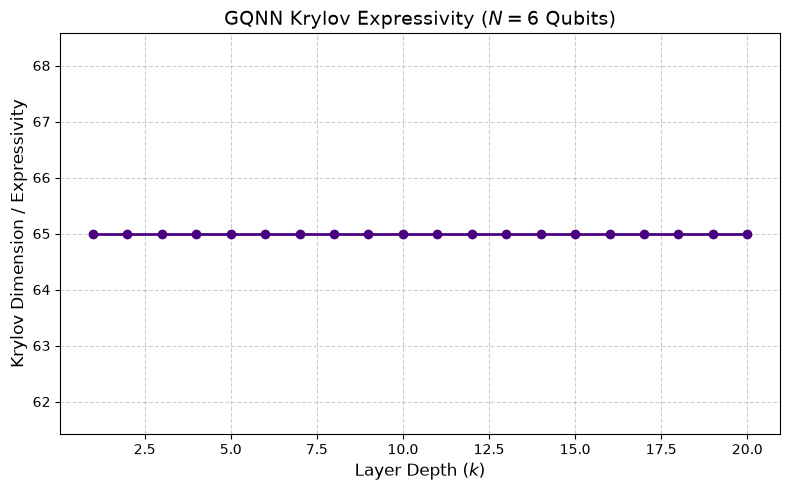

In [30]:
# Compute Krylov Expressivity for sub-networks 1 <= k <= N
results = compute_krylov_expressivity(
    n_layers=n_layers, 
    n_qubits=n_qubits, 
    weights=weights, 
    inputs=x, 
    O_0=Z0, 
    fm_style=feature_map
)

plot_krylov_expressivity(results, title="GQNN Krylov Expressivity ($N=6$ Qubits)")

In [31]:
# Dataset parameters

window_size = n_qubits
train_fraction = 0.8

# Generate a Mackey-Glass time series

series = mackey_glass()

train_series, test_series, scaler = split_and_scale_series(
    series,
    train_fraction=train_fraction,
)

X_train, y_train = create_io_pairs(
    train_series,
    window_size=window_size,
)

X_test, y_test = create_io_pairs(
    test_series,
    window_size=window_size,
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

Training samples: 1060
Testing samples : 261


In [32]:
def predict(weights, x):
    return model(x, weights)[0]


def mse(weights, X, y):
    predictions = np.array([
        predict(weights, x)
        for x in X
    ])
    return np.mean((predictions - y) ** 2)

In [33]:
optimizer = qml.AdamOptimizer(stepsize=0.02)

epochs = 100

train_loss = []
test_loss = []

In [ ]:
weights_current = weights.copy()

for epoch in range(epochs):

    weights_current = optimizer.step(
        lambda w: mse(w, X_train, y_train),
        weights_current,
    )

    train = mse(weights_current, X_train, y_train)
    test = mse(weights_current, X_test, y_test)

    train_loss.append(train)
    test_loss.append(test)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} "
            f"train={train:.6f} "
            f"test={test:.6f}"
        )

Epoch   0 train=0.408829 test=0.424495
